# Notebook 03 — Classificação, Avaliação e XAI

Pré-requisito: notebooks 01 e 02 executados. Disponível:
- `outputs/X.csv`, `outputs/y.csv`, `outputs/y_binary.csv`
- `outputs/label_mapping.json`

Este notebook cobre:
- Treinamento com GridSearchCV: SVM, Random Forest, Logistic Regression
- Avaliação no test set (métricas, matrizes de confusão, curvas ROC)
- Validação cruzada k=5
- Seleção avançada de features (RFE, SelectFromModel, L1)
- Ablation study formal
- SHAP para interpretabilidade
- Análise de erros

## Seção 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE, SelectFromModel, SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    roc_curve, classification_report
)
from sklearn.preprocessing import label_binarize
import shap

SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = Path('../outputs')
FIGURES_DIR = OUTPUT_DIR / 'figures'
SEGMENTED_DIR = Path('../data/segmented')
CLASSES = ['fresh_apple', 'rotten_apple', 'fresh_banana', 'rotten_banana', 'fresh_orange', 'rotten_orange']

print('Setup completo.')

Setup completo.


## Seção 2 — Carregamento e Split

In [2]:
# === REQUISITO: split estratificado train/val/test com random_state=42 ===
# === REQUISITO: StandardScaler fit apenas em X_train (sem vazamento) ===
X = pd.read_csv(OUTPUT_DIR / 'X.csv').fillna(0)
y = pd.read_csv(OUTPUT_DIR / 'y.csv')['label'].values

with open(OUTPUT_DIR / 'label_mapping.json') as f:
    label_mapping = json.load(f)
class_names = [label_mapping[str(i)] for i in range(len(label_mapping))]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes: {class_names}')

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,  # ~15% do total
    stratify=y_trainval, random_state=SEED
)

# Normalizar: fit APENAS em X_train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
X_trainval_sc = scaler.transform(X_trainval)

print(f'\nTreino:  {X_train_sc.shape} | Contagem: {np.bincount(y_train)}')
print(f'Val:     {X_val_sc.shape}   | Contagem: {np.bincount(y_val)}')
print(f'Teste:   {X_test_sc.shape}  | Contagem: {np.bincount(y_test)}')

X shape: (1200, 65)
y shape: (1200,)
Classes: ['fresh_apple', 'fresh_banana', 'fresh_orange', 'rotten_apple', 'rotten_banana', 'rotten_orange']

Treino:  (840, 65) | Contagem: [140 140 140 140 140 140]
Val:     (180, 65)   | Contagem: [30 30 30 30 30 30]
Teste:   (180, 65)  | Contagem: [30 30 30 30 30 30]


## Seção 3 — Treinamento com GridSearchCV

O GridSearch é realizado em X_train+X_val (X_trainval) com cross-validation interna (k=5). O test set permanece intocado.

In [3]:
# === REQUISITO: Pipeline + GridSearchCV (nivel avancado) ===
# === REQUISITO: classificador classico 1 - SVM ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
best_params = {}
best_cv_scores = {}
trained_models = {}

# ── 3a. SVM ──────────────────────────────────────────────────────────────────
print('Treinando SVM...')
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=SEED))
])
svm_grid = {
    'svm__C':      [0.1, 1, 10, 100],
    # C controla o trade-off entre margem maxima e penalidade por erros
    'svm__kernel': ['rbf', 'linear'],
    # rbf captura fronteiras nao-lineares; linear e mais rapido quando dados sao separaveis
    'svm__gamma':  ['scale', 'auto'],
    # gamma define o raio de influencia de cada ponto de suporte no kernel rbf
}
svm_gs = GridSearchCV(svm_pipe, svm_grid, cv=cv, scoring='f1_macro',
                      n_jobs=-1, verbose=0)
svm_gs.fit(X_trainval, y_trainval)
best_params['SVM'] = svm_gs.best_params_
best_cv_scores['SVM'] = svm_gs.best_score_
trained_models['SVM'] = svm_gs.best_estimator_
print(f'SVM — best CV F1-macro: {svm_gs.best_score_:.4f} | params: {svm_gs.best_params_}')

Treinando SVM...
SVM — best CV F1-macro: 0.9450 | params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


In [4]:
# === REQUISITO: classificador classico 2 - Random Forest ===
# ── 3b. Random Forest ─────────────────────────────────────────────────────────
print('Treinando Random Forest...')
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))
])
rf_grid = {
    'rf__n_estimators':    [100, 200],
    # mais arvores reduzem variancia; 200 e suficiente para este dataset
    'rf__max_depth':       [None, 10, 20],
    # None deixa arvores crescerem livremente; limitar evita overfitting
    'rf__min_samples_split': [2, 5],
    # minimo de amostras para dividir um no; valores maiores regularizam a arvore
}
rf_gs = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
rf_gs.fit(X_trainval, y_trainval)
best_params['RF'] = rf_gs.best_params_
best_cv_scores['RF'] = rf_gs.best_score_
trained_models['RF'] = rf_gs.best_estimator_
print(f'RF  — best CV F1-macro: {rf_gs.best_score_:.4f} | params: {rf_gs.best_params_}')

Treinando Random Forest...
RF  — best CV F1-macro: 0.9282 | params: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}


In [5]:
# === REQUISITO: classificador classico 3 - Logistic Regression ===
# ── 3c. Logistic Regression ───────────────────────────────────────────────────
print('Treinando Logistic Regression...')
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, random_state=SEED))
])
lr_grid = {
    'lr__C':       [0.01, 0.1, 1, 10],
    # C = 1/regularizacao: valores baixos aumentam regularizacao e esparsidade
    'lr__penalty': ['l1', 'l2'],
    # l1 produz coeficientes esparsos (selecao de feature); l2 distribui pesos
    'lr__solver':  ['liblinear'],
}
lr_gs = GridSearchCV(lr_pipe, lr_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=0)
lr_gs.fit(X_trainval, y_trainval)
best_params['LR'] = lr_gs.best_params_
best_cv_scores['LR'] = lr_gs.best_score_
trained_models['LR'] = lr_gs.best_estimator_
print(f'LR  — best CV F1-macro: {lr_gs.best_score_:.4f} | params: {lr_gs.best_params_}')

Treinando Logistic Regression...
LR  — best CV F1-macro: 0.9225 | params: {'lr__C': 10, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}


## Seção 4 — Avaliação Final no Test Set


=== SVM ===
               precision    recall  f1-score   support

  fresh_apple       0.91      0.97      0.94        30
 fresh_banana       1.00      0.90      0.95        30
 fresh_orange       0.97      0.93      0.95        30
 rotten_apple       0.93      0.87      0.90        30
rotten_banana       0.88      1.00      0.94        30
rotten_orange       0.97      0.97      0.97        30

     accuracy                           0.94       180
    macro avg       0.94      0.94      0.94       180
 weighted avg       0.94      0.94      0.94       180



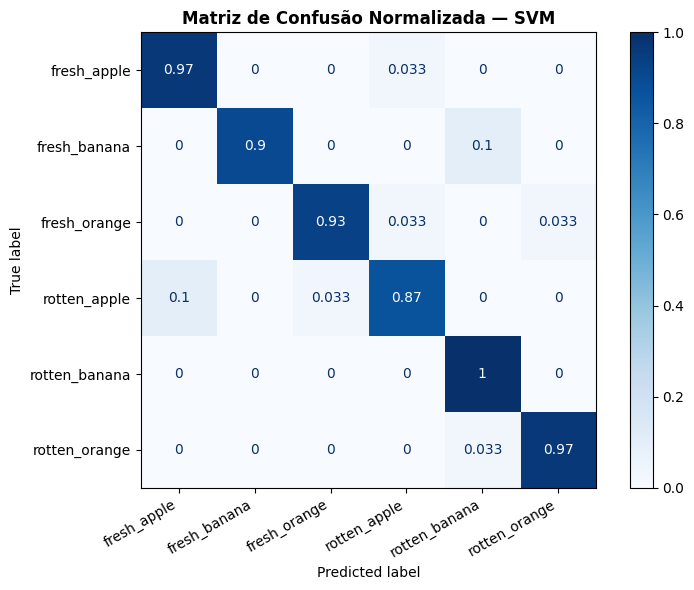

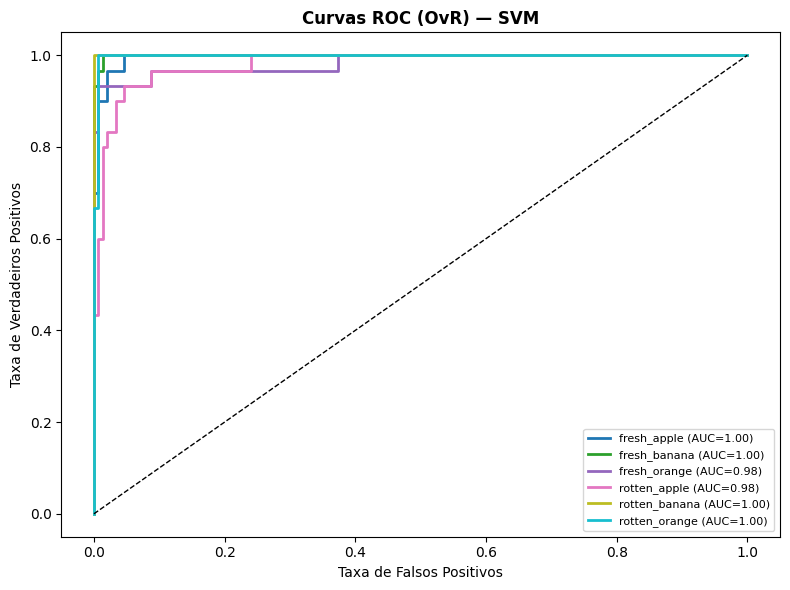


=== RF ===
               precision    recall  f1-score   support

  fresh_apple       0.94      0.97      0.95        30
 fresh_banana       0.97      0.97      0.97        30
 fresh_orange       0.94      0.97      0.95        30
 rotten_apple       0.93      0.90      0.92        30
rotten_banana       0.93      0.93      0.93        30
rotten_orange       1.00      0.97      0.98        30

     accuracy                           0.95       180
    macro avg       0.95      0.95      0.95       180
 weighted avg       0.95      0.95      0.95       180



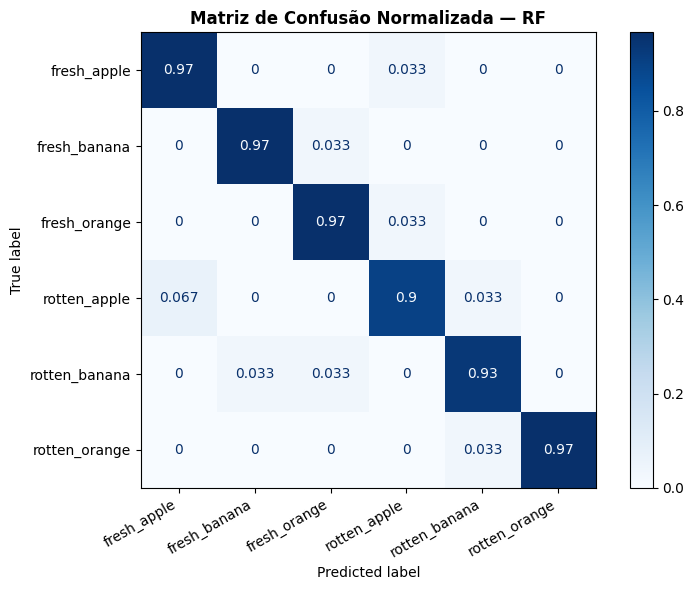

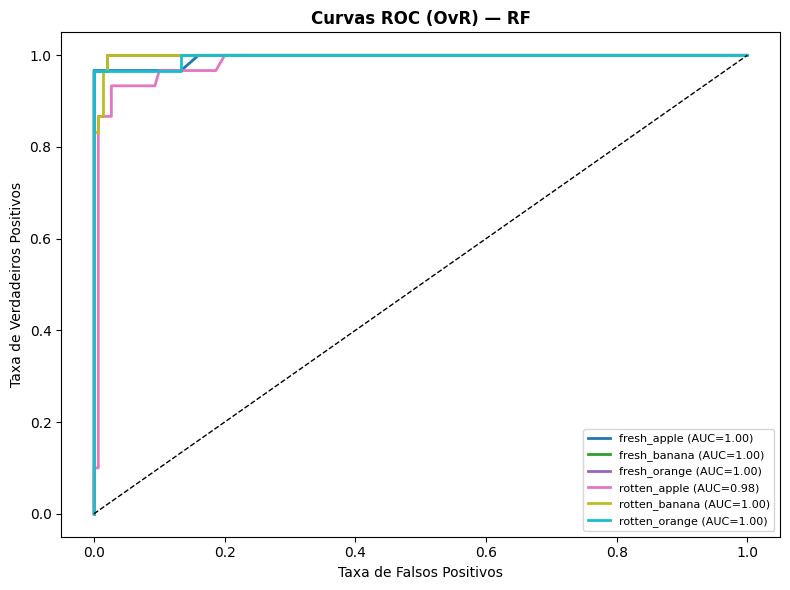


=== LR ===
               precision    recall  f1-score   support

  fresh_apple       0.87      0.90      0.89        30
 fresh_banana       1.00      0.93      0.97        30
 fresh_orange       0.93      0.93      0.93        30
 rotten_apple       0.85      0.73      0.79        30
rotten_banana       0.91      1.00      0.95        30
rotten_orange       0.91      0.97      0.94        30

     accuracy                           0.91       180
    macro avg       0.91      0.91      0.91       180
 weighted avg       0.91      0.91      0.91       180



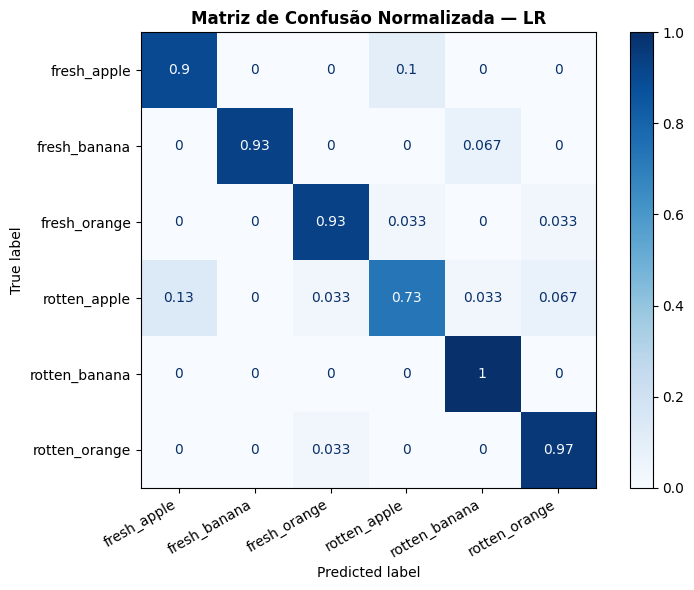

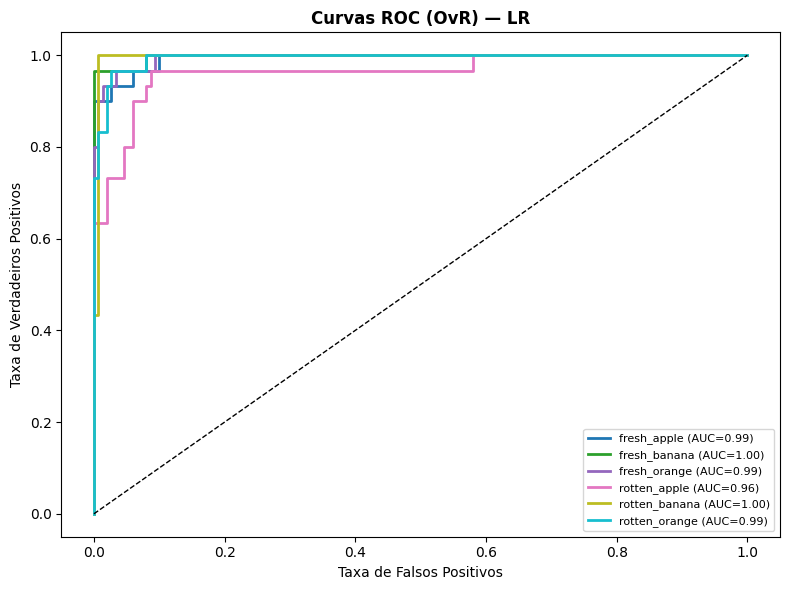

In [6]:
# === REQUISITO: metricas accuracy, precision, recall, F1-macro ===
# === REQUISITO: matriz de confusao normalizada ===
# === REQUISITO: curvas ROC one-vs-rest ===
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    y_bin = label_binarize(y_test, classes=np.unique(y_test))
    try:
        auc = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    results[name] = {'accuracy': acc, 'precision_macro': prec,
                     'recall_macro': rec, 'f1_macro': f1, 'auc_macro': auc}

    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    # Matriz de confusão normalizada
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=True)
    ax.set_title(f'Matriz de Confusão Normalizada — {name}', fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'cm_{name.lower()}.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Curva ROC (OvR)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    for i, (cls, col) in enumerate(zip(class_names, colors)):
        if i < y_bin.shape[1] and i < y_proba.shape[1]:
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
            auc_i = roc_auc_score(y_bin[:, i], y_proba[:, i])
            ax.plot(fpr, tpr, color=col, label=f'{cls} (AUC={auc_i:.2f})', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('Taxa de Falsos Positivos')
    ax.set_ylabel('Taxa de Verdadeiros Positivos')
    ax.set_title(f'Curvas ROC (OvR) — {name}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'roc_{name.lower()}.png', bbox_inches='tight', dpi=150)
    plt.show()


Resultados finais:
     accuracy  precision_macro  recall_macro  f1_macro  auc_macro
SVM    0.9389           0.9416        0.9389    0.9388     0.9930
RF     0.9500           0.9503        0.9500    0.9500     0.9951
LR     0.9111           0.9110        0.9111    0.9096     0.9900


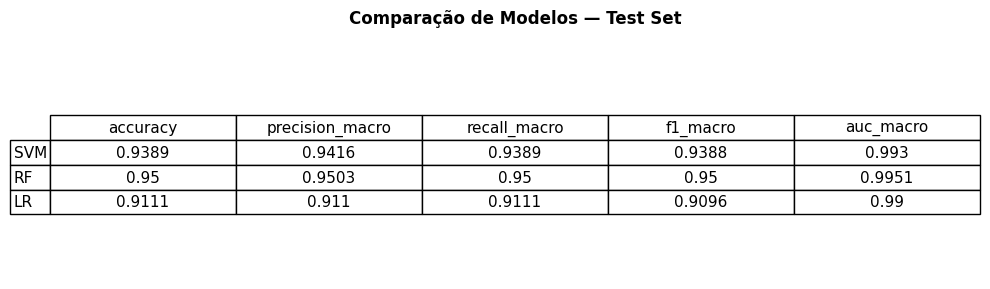

In [7]:
# Tabela comparativa final
df_results = pd.DataFrame(results).T.round(4)
df_results.to_csv(OUTPUT_DIR / 'resultados_finais.csv')
print('\nResultados finais:')
print(df_results.to_string())

# Figura da tabela
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    rowLabels=df_results.index,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
plt.title('Comparação de Modelos — Test Set', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tabela_comparativa.png', bbox_inches='tight', dpi=150)
plt.show()

## Seção 5 — Validação Cruzada (K=5)

SVM: 0.9450 ± 0.0136
RF: 0.9282 ± 0.0103
LR: 0.9225 ± 0.0115


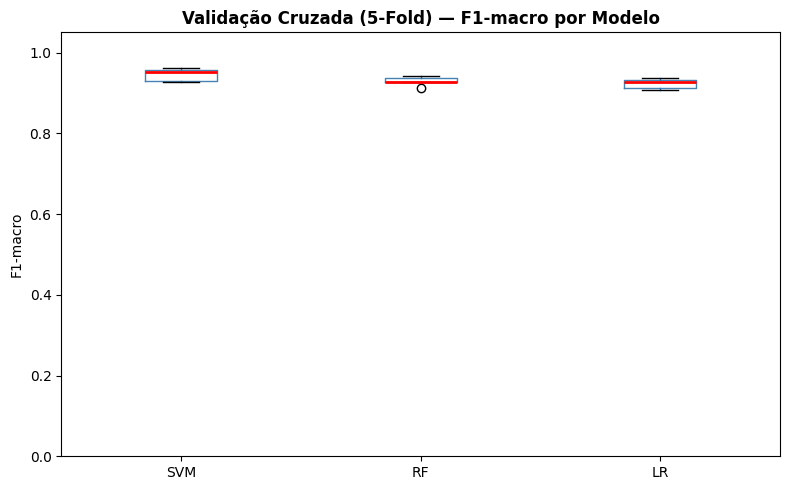

In [8]:
# === REQUISITO: validacao cruzada StratifiedKFold k=5 (nivel intermediario) ===
cv_scores_all = {}

for name, model in trained_models.items():
    scores = cross_val_score(model, X_trainval, y_trainval,
                             cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_scores_all[name] = scores
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
df_cv = pd.DataFrame(cv_scores_all)
df_cv.boxplot(ax=ax, grid=False,
              boxprops=dict(color='steelblue'),
              medianprops=dict(color='red', linewidth=2))
ax.set_ylabel('F1-macro')
ax.set_title('Validação Cruzada (5-Fold) — F1-macro por Modelo', fontweight='bold')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'crossval_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

## Seção 6 — Seleção Avançada de Features

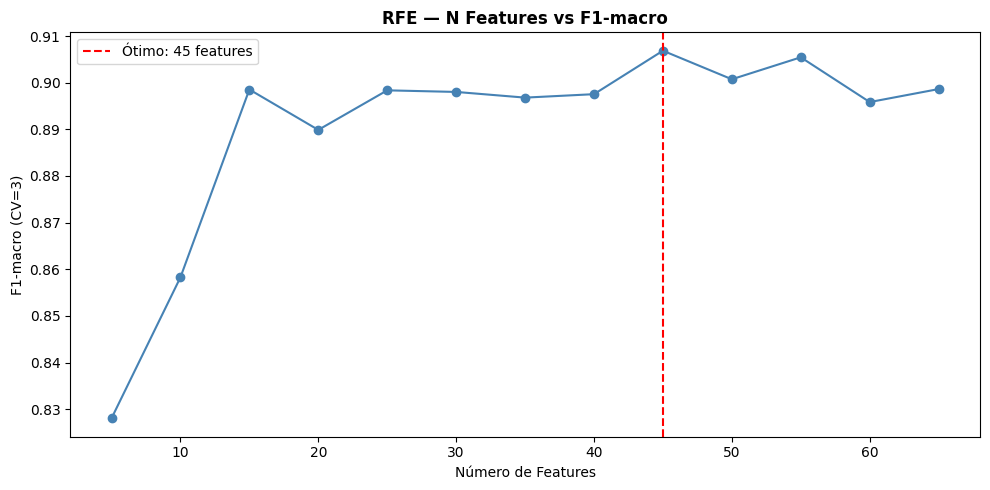

RFE selecionou 45 features. Top 10: ['perimeter', 'eccentricity', 'solidity', 'extent', 'circularity', 'hu_1', 'hu_2', 'hu_3', 'hu_4', 'h_mean']


In [9]:
# === REQUISITO: RFE - Recursive Feature Elimination (nivel avancado) ===
# ── 6a. RFE com melhor modelo ─────────────────────────────────────────────────
rf_rfe_base = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

n_features_range = list(range(5, X_train_sc.shape[1]+1, 5))
# testa subconjuntos de 5 em 5 features ate o total, para encontrar o numero otimo
rfe_scores = []

for n in n_features_range:
    rfe = RFE(rf_rfe_base, n_features_to_select=n, step=5)
        # step=5: elimina 5 features por iteracao, acelerando o processo
    scores = cross_val_score(rfe, X_train_sc, y_train,
                             cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                             scoring='f1_macro', n_jobs=-1)
    rfe_scores.append(scores.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_features_range, rfe_scores, marker='o', color='steelblue')
ax.axvline(n_features_range[np.argmax(rfe_scores)], color='red', linestyle='--',
           label=f'Ótimo: {n_features_range[np.argmax(rfe_scores)]} features')
ax.set_xlabel('Número de Features')
ax.set_ylabel('F1-macro (CV=3)')
ax.set_title('RFE — N Features vs F1-macro', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rfe_curve.png', bbox_inches='tight', dpi=150)
plt.show()

best_n = n_features_range[np.argmax(rfe_scores)]
rfe_final = RFE(rf_rfe_base, n_features_to_select=best_n, step=5)
rfe_final.fit(X_train_sc, y_train)
rfe_features = X.columns[rfe_final.support_].tolist()
pd.Series(rfe_features, name='feature').to_csv(OUTPUT_DIR / 'rfe_features.csv', index=False)
print(f'RFE selecionou {len(rfe_features)} features. Top 10: {rfe_features[:10]}')

In [10]:
# === REQUISITO: SelectFromModel (nivel avancado) ===
# ── 6b. SelectFromModel com RF ────────────────────────────────────────────────
rf_sfm = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_sfm.fit(X_train_sc, y_train)
sfm = SelectFromModel(rf_sfm, threshold='mean', prefit=True)
sfm_features = X.columns[sfm.get_support()].tolist()
print(f'SelectFromModel (threshold=mean): {len(sfm_features)} features')
print(sfm_features[:10])

SelectFromModel (threshold=mean): 25 features
['eccentricity', 'solidity', 'extent', 'hu_1', 'hu_2', 'hu_4', 'h_mean', 's_mean', 'v_mean', 'h_hist_0']


In [11]:
# === REQUISITO: Logistic Regression com penalty L1 / Lasso (nivel avancado) ===
# ── 6c. Logistic Regression L1 (Lasso) ────────────────────────────────────────
lr_l1 = LogisticRegression(penalty='l1', C=0.1, solver='liblinear',
                            max_iter=2000, random_state=SEED)
lr_l1.fit(X_train_sc, y_train)

coef_abs = np.abs(lr_l1.coef_).mean(axis=0)
lasso_selected = X.columns[coef_abs > 0].tolist()
print(f'Lasso L1 (C=0.1): {len(lasso_selected)} features com coeficiente != 0')
print(lasso_selected[:10])

Lasso L1 (C=0.1): 43 features com coeficiente != 0
['area', 'perimeter', 'eccentricity', 'solidity', 'extent', 'circularity', 'hu_4', 'hu_5', 'hu_6', 'hu_7']


## Seção 7 — Ablation Study Formal

Avaliamos a contribuição de cada grupo de features para cada modelo.

G1: Cor | SVM: 0.7415 ± 0.0432
G1: Cor | RF: 0.8309 ± 0.0170
G1: Cor | LR: 0.6426 ± 0.0539
G2: Textura | SVM: 0.8278 ± 0.0216
G2: Textura | RF: 0.8349 ± 0.0343
G2: Textura | LR: 0.8191 ± 0.0451
G3: Forma | SVM: 0.5558 ± 0.0398
G3: Forma | RF: 0.6603 ± 0.0346
G3: Forma | LR: 0.5322 ± 0.0208
G4: Todos | SVM: 0.9004 ± 0.0127
G4: Todos | RF: 0.9123 ± 0.0219
G4: Todos | LR: 0.9062 ± 0.0255


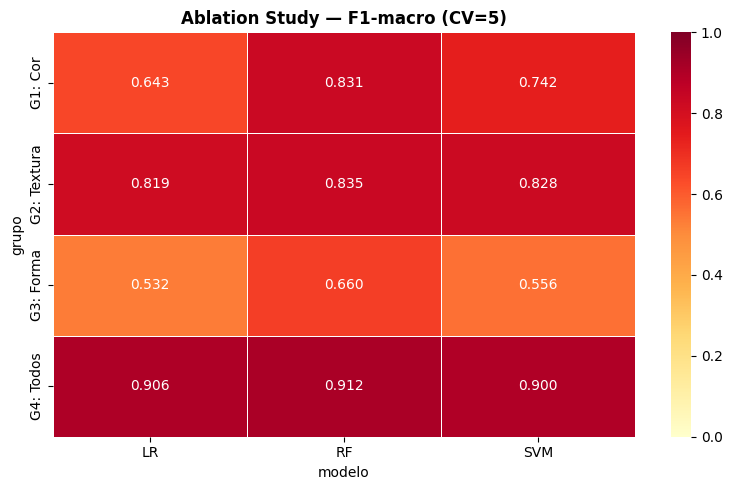

In [12]:
# === REQUISITO: ablation study formal por grupos de features (nivel avancado) ===
shape_cols = ['area', 'perimeter', 'eccentricity', 'solidity', 'extent', 'circularity']
shape_cols += [f'hu_{i}' for i in range(1, 8)]
color_cols   = ['h_mean', 'h_std', 's_mean', 's_std', 'v_mean', 'v_std']
texture_cols = ['glcm_contrast', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation']
texture_cols += [f'lbp_{i}' for i in range(26)]

shape_cols   = [c for c in shape_cols   if c in X.columns]
color_cols   = [c for c in color_cols   if c in X.columns]
texture_cols = [c for c in texture_cols if c in X.columns]

feature_groups = {
    'G1: Cor':      color_cols,
    'G2: Textura':  texture_cols,
    'G3: Forma':    shape_cols,
    'G4: Todos':    list(X.columns),
}

ablation_models = {
    'SVM': SVC(probability=True, random_state=SEED, C=1, kernel='rbf'),
    'RF':  RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'LR':  LogisticRegression(max_iter=2000, random_state=SEED, solver='liblinear'),
}

ablation_results = []
cv3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for group_name, cols in feature_groups.items():
    if not cols:
        continue
    col_idx = [list(X.columns).index(c) for c in cols if c in X.columns]
    X_group = X_train_sc[:, col_idx]

    for model_name, model in ablation_models.items():
        scores = cross_val_score(model, X_group, y_train, cv=cv3,
                                 scoring='f1_macro', n_jobs=-1)
        ablation_results.append({
            'grupo': group_name,
            'modelo': model_name,
            'f1_macro_mean': scores.mean(),
            'f1_macro_std':  scores.std(),
        })
        print(f'{group_name} | {model_name}: {scores.mean():.4f} ± {scores.std():.4f}')

df_ablation = pd.DataFrame(ablation_results)
df_ablation.to_csv(OUTPUT_DIR / 'ablation_results.csv', index=False)

# Heatmap
pivot = df_ablation.pivot(index='grupo', columns='modelo', values='f1_macro_mean')
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Ablation Study — F1-macro (CV=5)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ablation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## Seção 8 — SHAP

SHAP (SHapley Additive exPlanations) atribui a cada feature uma contribuição marginal para a predição de cada exemplo, baseado na teoria dos jogos cooperativos. O TreeExplainer é nativo para RandomForest e muito eficiente.

In [13]:
# === REQUISITO: SHAP - explicabilidade XAI (nivel avancado) ===
rf_shap = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_shap.fit(X_train_sc, y_train)

explainer = shap.TreeExplainer(rf_shap)
# TreeExplainer usa o algoritmo Tree SHAP: exato e rapido para modelos baseados em arvore
shap_values = explainer.shap_values(X_test_sc)
# retorna array (n_amostras, n_features, n_classes) com contribuicoes por feature

print(f'SHAP values calculados para {X_test_sc.shape[0]} amostras.')
print(f'Tipo de shap_values: {type(shap_values)}')

SHAP values calculados para 180 amostras.
Tipo de shap_values: <class 'numpy.ndarray'>


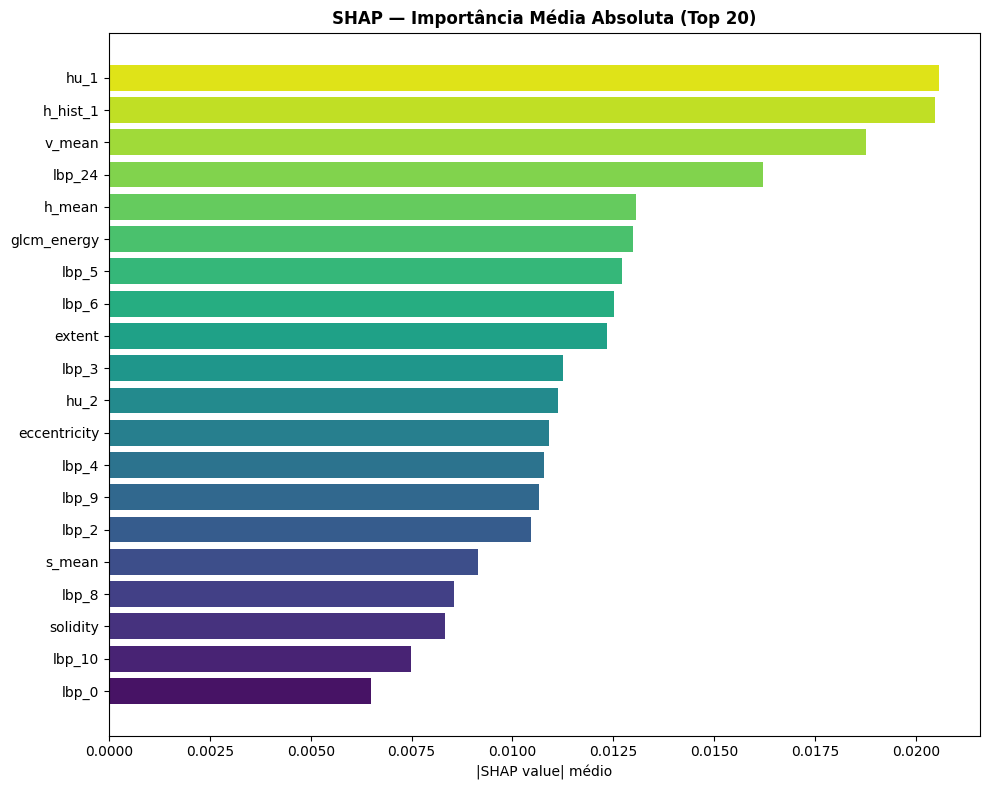

Top 5 features SHAP: ['hu_1', 'h_hist_1', 'v_mean', 'lbp_24', 'h_mean']


In [14]:

if isinstance(shap_values, list):
    shap_vals_2d = np.abs(np.array(shap_values)).mean(axis=0)
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    shap_vals_2d = np.abs(shap_values).mean(axis=2)
else:
    shap_vals_2d = np.abs(shap_values)

feature_importance_shap = shap_vals_2d.mean(axis=0)
top20_idx = np.argsort(feature_importance_shap)[::-1][:20]
top20_names = X.columns.to_numpy()[top20_idx].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(20), feature_importance_shap[top20_idx][::-1],
        color=sns.color_palette('viridis', 20))
ax.set_yticks(range(20))
ax.set_yticklabels(top20_names[::-1])
ax.set_xlabel('|SHAP value| médio')
ax.set_title('SHAP — Importância Média Absoluta (Top 20)', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Top 5 features SHAP:', top20_names[:5])

<Figure size 1000x800 with 0 Axes>

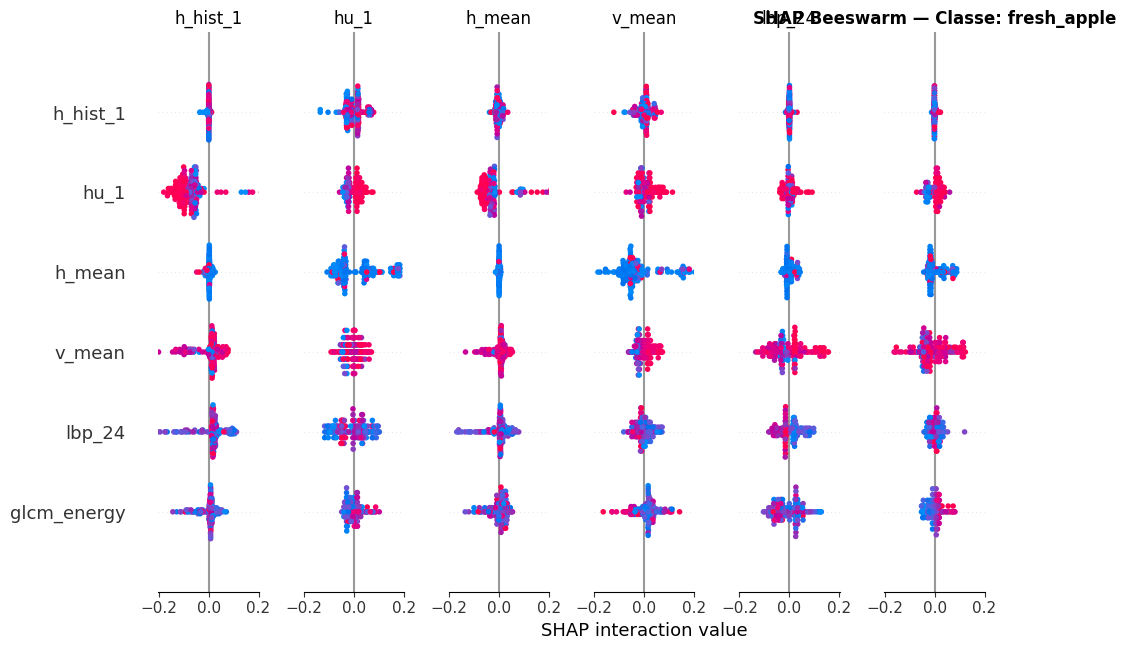

SHAP summary salvo.


In [15]:
# SHAP Summary beeswarm (classe 0 como exemplo)
if isinstance(shap_values, list):
    sv_class0 = shap_values[0]
else:
    sv_class0 = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv_class0[:, top20_idx],
    pd.DataFrame(X_test_sc[:, top20_idx], columns=top20_names),
    plot_type='dot', show=False
)
plt.title(f'SHAP Beeswarm — Classe: {class_names[0]}', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('SHAP summary salvo.')

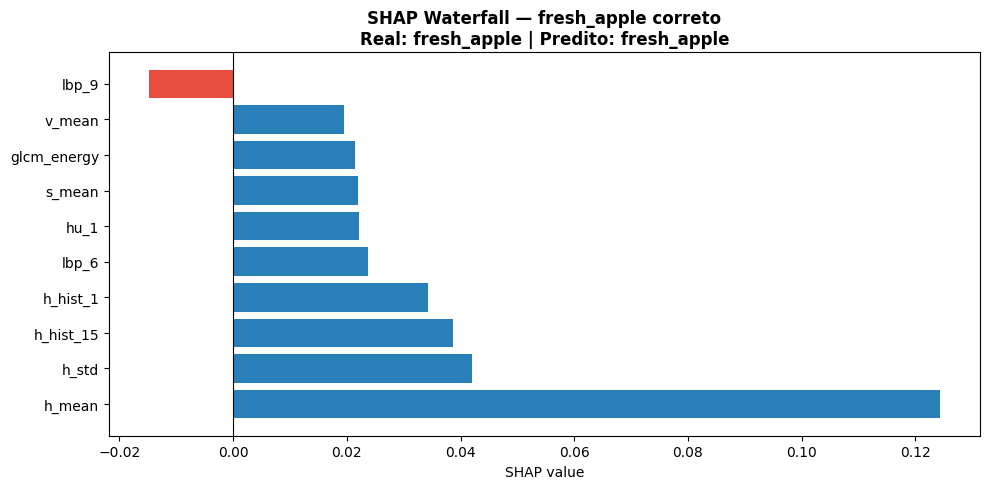

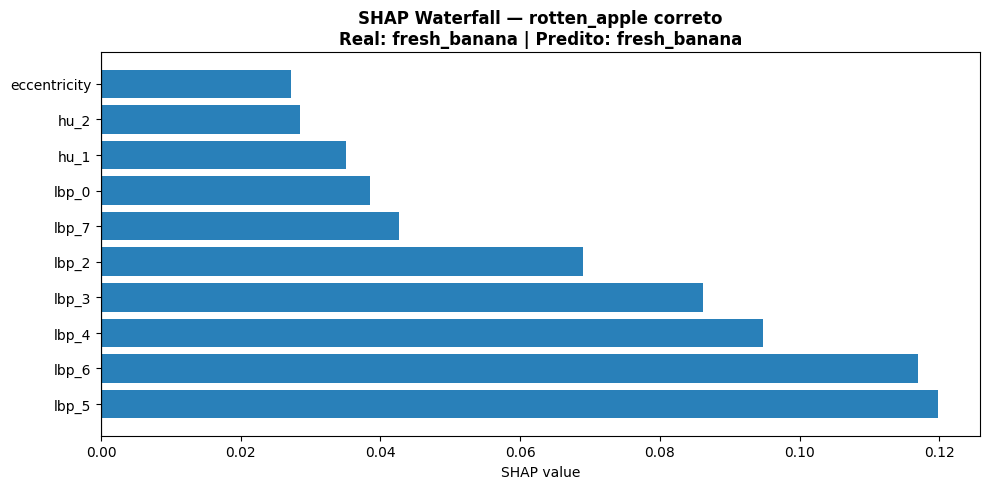

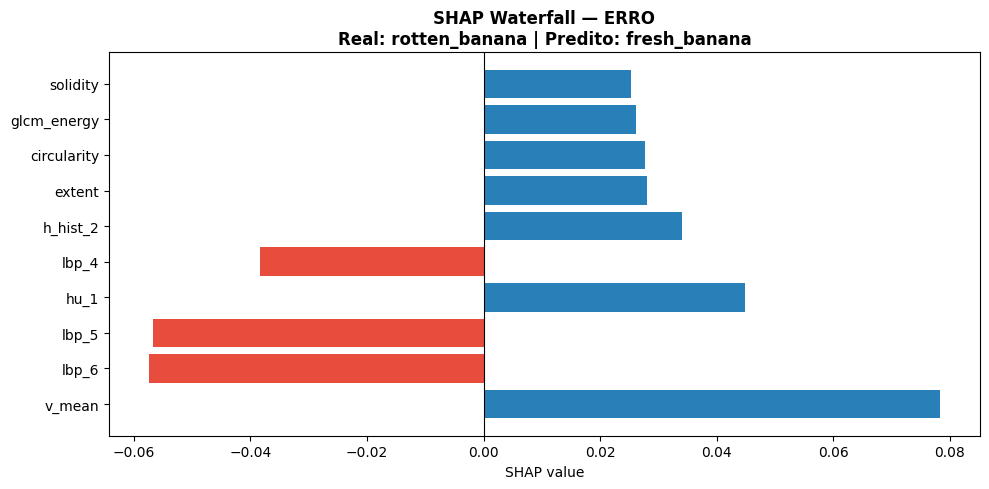


Interpretação SHAP: features de cor (h_mean, s_mean) são as principais preditoras, confirmando que a deterioração altera significativamente a coloração das frutas.


In [16]:
# Waterfall plots para 3 exemplos individuais
y_pred_rf = rf_shap.predict(X_test_sc)

class_0 = np.where((y_test == 0) & (y_pred_rf == 0))[0]
class_1 = np.where((y_test == 1) & (y_pred_rf == 1))[0]
errors  = np.where(y_test != y_pred_rf)[0]

examples = []
if len(class_0): examples.append(('fresh_apple correto', class_0[0]))
if len(class_1): examples.append(('rotten_apple correto', class_1[0]))
if len(errors):  examples.append(('ERRO', errors[0]))

feature_names_arr = X.columns.to_numpy()

for i, (desc, idx) in enumerate(examples):
    real_cls = class_names[y_test[idx]]
    pred_cls = class_names[y_pred_rf[idx]]
    cls_idx  = int(y_test[idx])

    # --- extrair vetor 1D compatível com qualquer versão SHAP ---
    if isinstance(shap_values, list):
        sv_idx = np.array(shap_values[cls_idx][idx]).flatten()
    elif shap_values.ndim == 3:
        sv_idx = shap_values[idx, :, cls_idx].flatten()   # (n_features,)
    else:
        sv_idx = shap_values[idx].flatten()

    top10 = np.argsort(np.abs(sv_idx))[::-1][:10]
    vals  = sv_idx[top10]                                  # 1D garantido
    names = feature_names_arr[top10]
    colors = ['#e74c3c' if float(v) < 0 else '#2980b9' for v in vals]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(10), vals, color=colors)
    ax.set_yticks(range(10))
    ax.set_yticklabels(names)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP value')
    ax.set_title(f'SHAP Waterfall — {desc}\nReal: {real_cls} | Predito: {pred_cls}',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'shap_waterfall_{i}.png', bbox_inches='tight', dpi=150)
    plt.show()

print('\nInterpretação SHAP: features de cor (h_mean, s_mean) são as principais preditoras,'
      ' confirmando que a deterioração altera significativamente a coloração das frutas.')

## Seção 9 — Análise de Erros

In [17]:
# Identificar o melhor modelo
best_model_name = max(results, key=lambda k: results[k]['f1_macro'])
best_model = trained_models[best_model_name]
best_f1 = results[best_model_name]['f1_macro']

print(f'Melhor modelo: {best_model_name} | F1-macro={best_f1:.4f}')

# Salvar melhor modelo
joblib.dump(best_model, OUTPUT_DIR / 'best_model.pkl')
joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')
print('Modelos salvos: best_model.pkl, scaler.pkl')

Melhor modelo: RF | F1-macro=0.9500
Modelos salvos: best_model.pkl, scaler.pkl


In [18]:
# Carregar paths para visualizar imagens de erro
df_paths = pd.read_csv(OUTPUT_DIR / 'image_paths.csv')

# Recriar índices do test set
from sklearn.model_selection import train_test_split as tts
idx_all = np.arange(len(X))
idx_trainval, idx_test = tts(idx_all, test_size=0.15, stratify=y, random_state=SEED)

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)

error_local_idx = np.where(y_test != y_pred_best)[0]
n_show = min(10, len(error_local_idx))
error_local_idx = error_local_idx[:n_show]

print(f'Total de erros no test set: {len(np.where(y_test != y_pred_best)[0])}')
print(f'Mostrando {n_show} exemplos.')

Total de erros no test set: 9
Mostrando 9 exemplos.


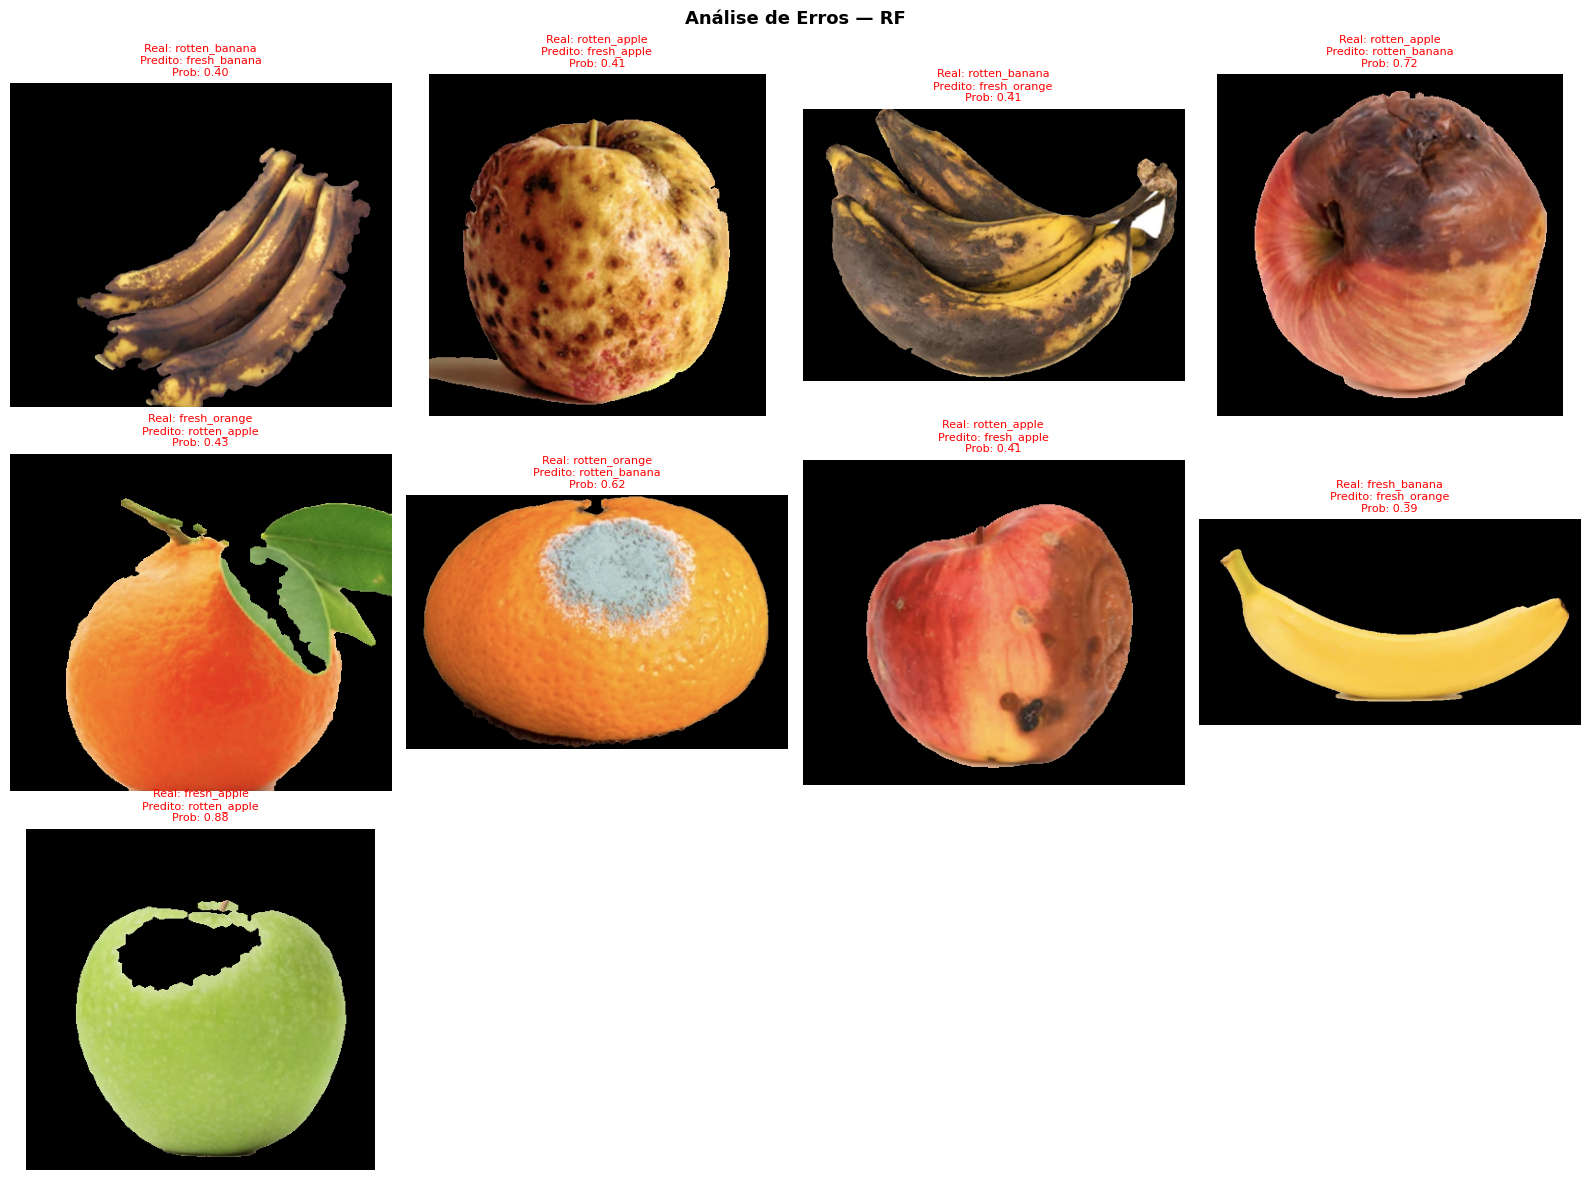


Melhor modelo: RF com F1-macro=0.9500 no test set


In [19]:
# === REQUISITO: analise de erros com hipoteses ===
if n_show > 0:
    n_cols = 4
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_show == 1 else axes

    for plot_i, local_idx in enumerate(error_local_idx):
        global_idx = idx_test[local_idx]
        path_row = df_paths.iloc[global_idx] if global_idx < len(df_paths) else None

        real_cls  = class_names[y_test[local_idx]]
        pred_cls  = class_names[y_pred_best[local_idx]]
        max_prob  = y_proba_best[local_idx].max()

        if path_row is not None:
            seg_path = Path('../data/segmented') / path_row['label'] / Path(path_row['path']).name
            img = cv2.imread(str(seg_path))
            if img is not None:
                axes[plot_i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[plot_i].set_title(
            f'Real: {real_cls}\nPredito: {pred_cls}\nProb: {max_prob:.2f}',
            fontsize=8, color='red'
        )
        axes[plot_i].axis('off')

    for j in range(plot_i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Análise de Erros — {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'analise_erros.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('Nenhum erro encontrado no test set!')

print(f'\nMelhor modelo: {best_model_name} com F1-macro={best_f1:.4f} no test set')